In [1]:
print("Test")

Test


In [2]:
# Imports
from pathlib import Path
import sys
import pathlib

# Add the project's root directory to the Python path
sys.path.append(pathlib.Path("../").resolve().as_posix())

# Configurations

# Paths
DATA_DIR = Path("../data/")
ENC2017_ROOT = DATA_DIR / "enc2017"
UD_ET_EDT_ROOT = DATA_DIR / "ud_et_edt"
HOMONYMS_ROOT = DATA_DIR / "homonymous_word_forms"

ENC2017_DIRS = {
    "processed": ENC2017_ROOT / "processed",
    "raw": ENC2017_ROOT / "raw",
}

UD_ET_EDT_DIRS = {
    "processed": UD_ET_EDT_ROOT / "processed",
    "raw": UD_ET_EDT_ROOT / "raw",
}

HOMONYMS_DIRS = {
    "processed": HOMONYMS_ROOT / "processed",
    "annotations": HOMONYMS_ROOT / "annotations",
}

OUTPUT_DIR = Path("../outputs/")

In [3]:
import sys
import os
import pandas as pd
import json
import pathlib
import numpy as np
import torch

from scripts.model.model import (
    initialize_model,
    train_token_classification,
)

In [8]:
output_dir = "./testing/"
train_path = HOMONYMS_DIRS["processed"] / "homonyms_train.parquet"
eval_path = UD_ET_EDT_DIRS["processed"] / "UD_dev.csv"
model_dir = "../models/NER_mudel_v2/"
output_dir = "./NER_mudel_v2_homonym_early_stopping/"
ignore_placeholders = True
dry_run = False
seed = 42
train_batch_size = 8
learning_rate = 5e-7
num_train_epochs = 10
use_cuda = torch.cuda.is_available()

In [9]:
train_df = pd.read_parquet(train_path) if train_path else None
eval_df = pd.read_csv(eval_path) if eval_path else None

# Read labels from the unique labels json
with open("../outputs/unique_labels_old.json", "r") as f:
    labels = json.load(f)


model_bundle = initialize_model(model_dir, labels, use_Roberta_tokenizer=False)

E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\model.py:112: UserWarning: Using label mapping from model `id2label` in checkpoint.
  warnings.warn("Using label mapping from model `id2label` in checkpoint.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [10]:
print(len(train_df))
display(train_df.head())
print(len(eval_df))
display(eval_df.head())

134822


,sentence_id,words,form,pos,labels,infl_type,source
0,0,Edinburghi,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-0...
1,0,agulite,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-0...
2,0,mehe,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-0...
3,0,Irvine,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-0...
4,0,Welshi,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-0...


44748


,sentence_id,words,form,pos,file_prefix,source,labels
0,0,Aga,NaN,J,aja_ee199920,et_edt-ud-dev_000.json,J
1,0,mulle,sg all,P,aja_ee199920,et_edt-ud-dev_000.json,sg all_P
2,0,tundub,b,V,aja_ee199920,et_edt-ud-dev_000.json,b_V
3,0,",",NaN,Z,aja_ee199920,et_edt-ud-dev_000.json,Z
4,0,et,NaN,J,aja_ee199920,et_edt-ud-dev_000.json,J


In [ ]:
# Replace labels that contain "T" with placeholder dash "-"
eval_df["labels"] = eval_df["labels"].apply(
    lambda label: "-" if ignore_placeholders and "T" in label else label
)

In [13]:
res = train_token_classification(
    model=model_bundle["model"],
    tokenizer=model_bundle["tokenizer"],
    train_df=train_df,
    label_list=labels,
    output_dir=output_dir,
    eval_df=eval_df,
    num_train_epochs=num_train_epochs,
    train_batch_size=train_batch_size,
    learning_rate=learning_rate,
    evaluate_during_training=False if eval_df is None else True,
    use_early_stopping=True,
    patience_n=1,
    early_stopping_method="f1",
    early_stopping_threshold=0.8,
    best_model_dir=os.path.join(output_dir, "best_model"),
    save_model_every_epoch=True,
    device=model_bundle["device"],
    silent=False,
    ignore_placeholders=ignore_placeholders,
    dry_run=dry_run,
    seed=seed,
)

print("Training finished. Results:")
print(res)

Epoch 1/10:   0%|          | 0/125 [00:00<?, ?it/s]

e:\Git_projects\EstNLTK\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Git_projects\EstNLTK\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Git_projects\EstNLTK\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Git_projects\EstNLTK\.venv\Lib\sit

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training finished. Results:
{'training_stats': {'train_loss': [0.7280395011901856], 'train_metrics': [{'loss': 0.6569059208631516, 'accuracy': 0.8379742429516185, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'report': {'D': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}, 'G': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}, 'K': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}, 'Y': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}, 'adt_H': {'precision': 0.6666666666666666, 'recall': 0.5925925925925926, 'f1-score': 0.6274509803921569, 'support': 27.0}, 'adt_S': {'precision': 0.5777777777777777, 'recall': 0.4, 'f1-score': 0.4727272727272727, 'support': 65.0}, 'pl g_A': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}, 'pl g_S': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}, 'pl n_P': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}, 'pl n_S': {'precision': 0

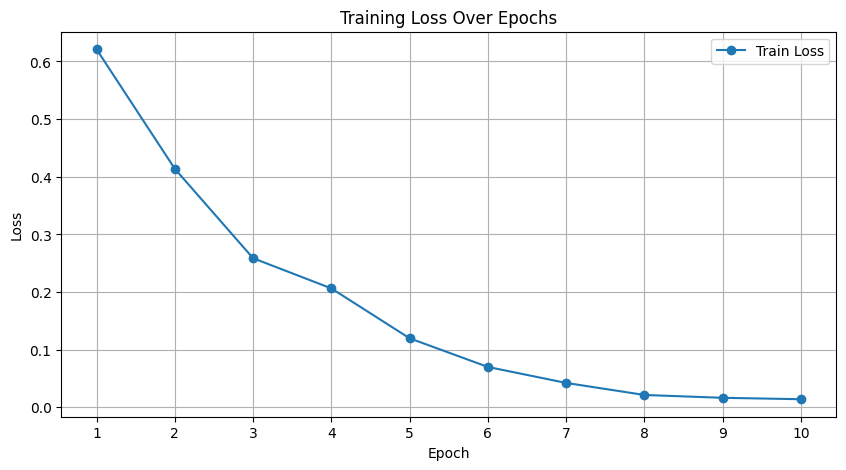

In [ ]:
import matplotlib.pyplot as plt

# Shift epoch numbers to start from 1 instead of 0
epochs = list(range(1, len(res["training_stats"]["train_loss"]) + 1))

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, res["training_stats"]["train_loss"], label="Train Loss", marker="o")
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid()
plt.savefig(output_dir + "training_loss.png")
plt.show()

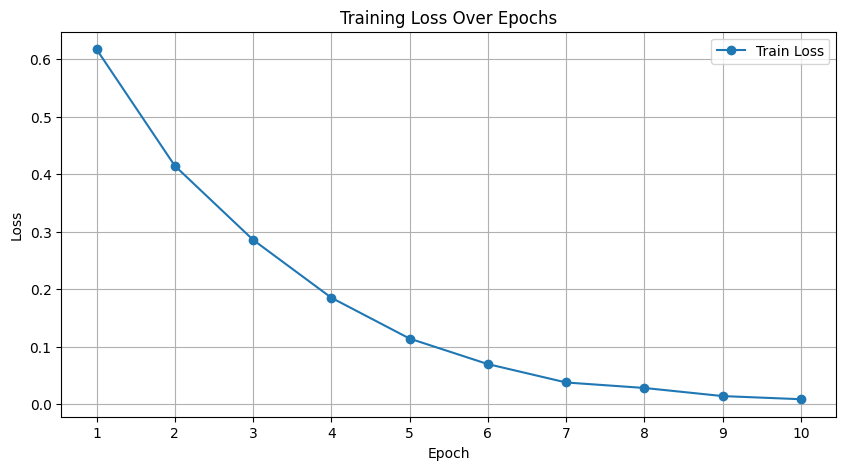

In [16]:
import matplotlib.pyplot as plt

# Shift epoch numbers to start from 1 instead of 0
epochs = list(range(1, len(res["training_stats"]["train_loss"]) + 1))

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, res["training_stats"]["train_loss"], label="Train Loss", marker="o")
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid()
plt.show()